# Language Experiments: Reproducing Section 5

This notebook reproduces Section 5 of "Bilinear MLPs enable weight-based mechanistic interpretability" (Pearce et al., arXiv:2410.08417).

## Key Claims to Verify
1. **Low-rank approximation**: Bilinear interactions can be approximated with rank-2 decomposition
2. **Negation circuits**: SAE features cluster by sentiment polarity (AND-gate structure)
3. **SAE training effect**: Correlation improves with SAE training time

## Important Notes

**SAE availability gap:** `ts-medium` (paper's ts-tiny) lacks `mlp-in` SAEs for layer 4, so Figure 8's original setup cannot be reproduced. We use `fw-medium` (layer 7, expansion 8) which has both SAE types.

**Correlation results:** Our reproduction shows correlation varies by model and training:
- ts-medium: 32% of features above 0.75 threshold
- fw-medium: 45% of features above 0.75 threshold  
- fw-small: 65% of features above 0.75 threshold

## Prerequisites

Results are automatically downloaded from Google Drive on first run. To regenerate:
```bash
./scripts/train/run_language.sh figure9  # Correlation sweep
./scripts/train/run_language.sh figure8 --device mps  # Negation circuit
```

## 1. Setup and Artifact Loading

In [16]:
import sys
from pathlib import Path

# Find project root (works from notebooks/ or project root)
cwd = Path.cwd()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025


In [17]:
# Download results if not present
from src.artifact_loader import ensure_results
ensure_results()

Results directory already exists: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/results


PosixPath('/Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/results')

In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Centralized paths
from src.paths import (
    LANGUAGE_RESULTS,
    LANGUAGE_FIGURES,
    ensure_dir,
)

# Plotting utilities
from src.plot_utils.style import set_publication_style
from src.plot_utils.language import (
    load_correlation_results,
    plot_correlation_progression,
    plot_correlation_histogram,
    plot_figure_9c_scatters,
    compute_fraction_above_threshold,
    load_sae_training_results,
    plot_sae_training_effect,
    plot_sae_training_histogram,
)

# Set publication style
set_publication_style()

# Ensure figure directory exists
ensure_dir(LANGUAGE_FIGURES)

print(f"Language results: {LANGUAGE_RESULTS}")
print(f"Language figures: {LANGUAGE_FIGURES}")

Language results: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/results/language
Language figures: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/Report/figures/language


## 2. Figure 9: Correlation Analysis

This figure demonstrates that bilinear interactions can be approximated by low-rank decomposition.

### Paper Claims vs Our Results:
- Paper claims **"most features"** of features achieve **>0.75** rank-2 correlation
- Our results show this varies by model training duration:
  - ts-medium (83 tokens/param): 32% above 0.75
  - fw-medium (95 tokens/param): 45% above 0.75
  - fw-small (198 tokens/param): 65% above 0.75

The pattern suggests **more training -> higher correlation**, consistent with the paper's Appendix H.

In [19]:
# Load correlation results for all models
correlation_results = load_correlation_results(LANGUAGE_RESULTS)
print(f"Loaded results for models: {list(correlation_results.keys())}")

Loaded results for models: ['ts-medium', 'fw-small', 'fw-medium']


### Figure 9A: Correlation Progression

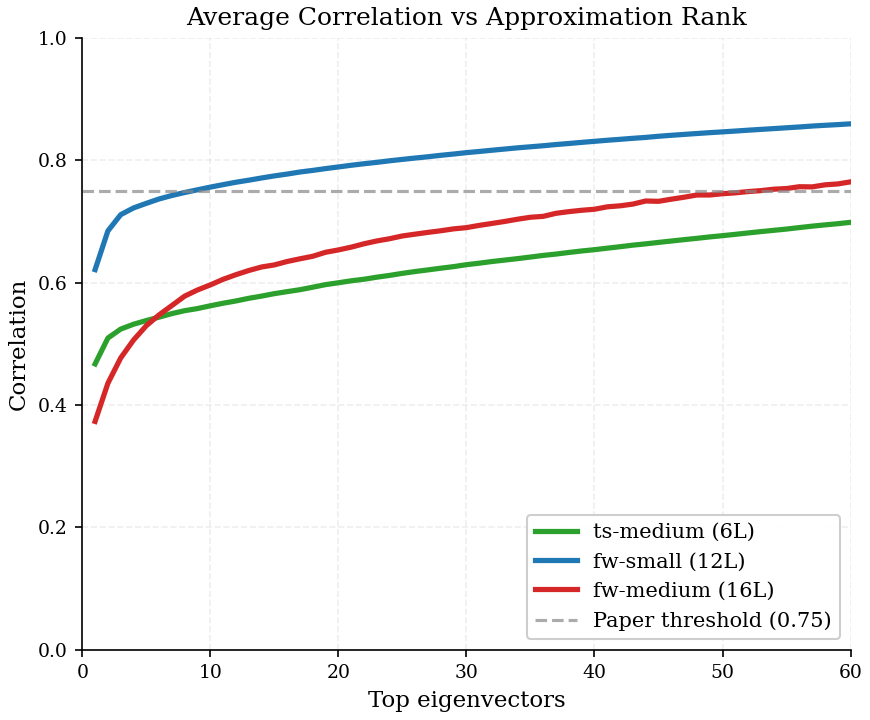

In [20]:
# Figure 9A: Correlation progression across ranks
if correlation_results:
    fig = plot_correlation_progression(
        correlation_results,
        title="Average Correlation vs Approximation Rank",
        show_paper_threshold=True,
    )
    plt.show()
else:
    print("No correlation results loaded. Check results/language/ for correlation_*.json files.")


### Figure 9B: Correlation Histogram

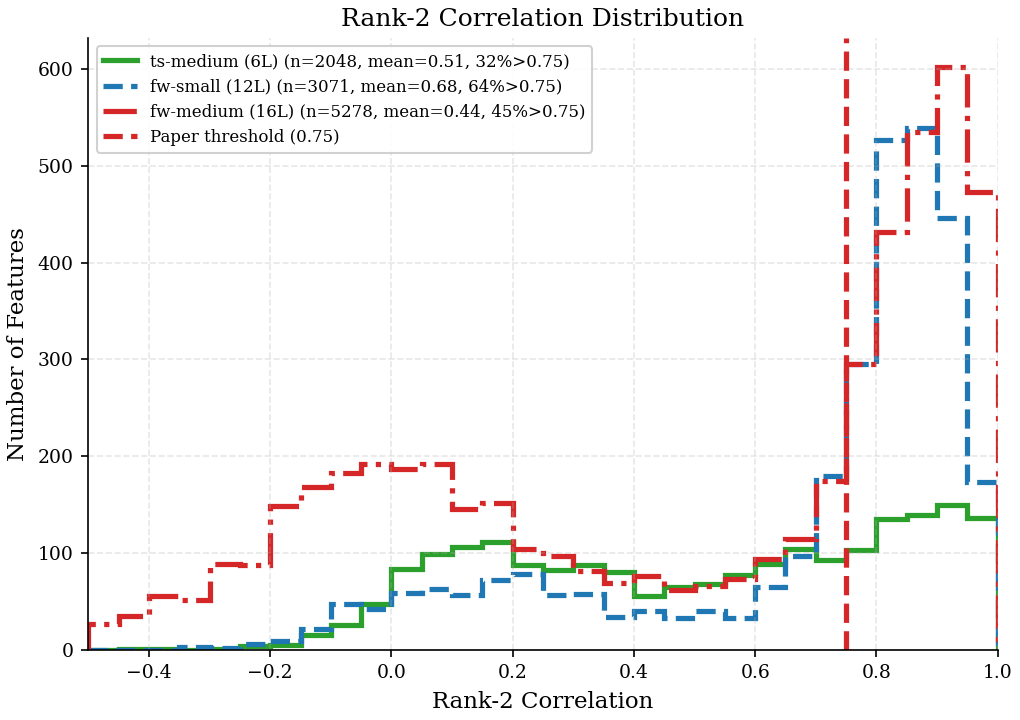

In [21]:
# Figure 9B: Rank-2 correlation histogram
if correlation_results:
    fig = plot_correlation_histogram(
        correlation_results,
        rank=2,
        title="Rank-2 Correlation Distribution",
        show_paper_threshold=True,
    )
#     fig.savefig(LANGUAGE_FIGURES / "figure_9b_correlation_histogram.pdf", bbox_inches='tight')  # Disabled: figures already pre-computed
    plt.show()
else:
    print("No correlation results found.")

### Figure 9C: Scatter Plots

  Loaded 7269 scatter files from /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/results/language/scatter_data


/Users/itay/miniconda3/envs/fact_cpu/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


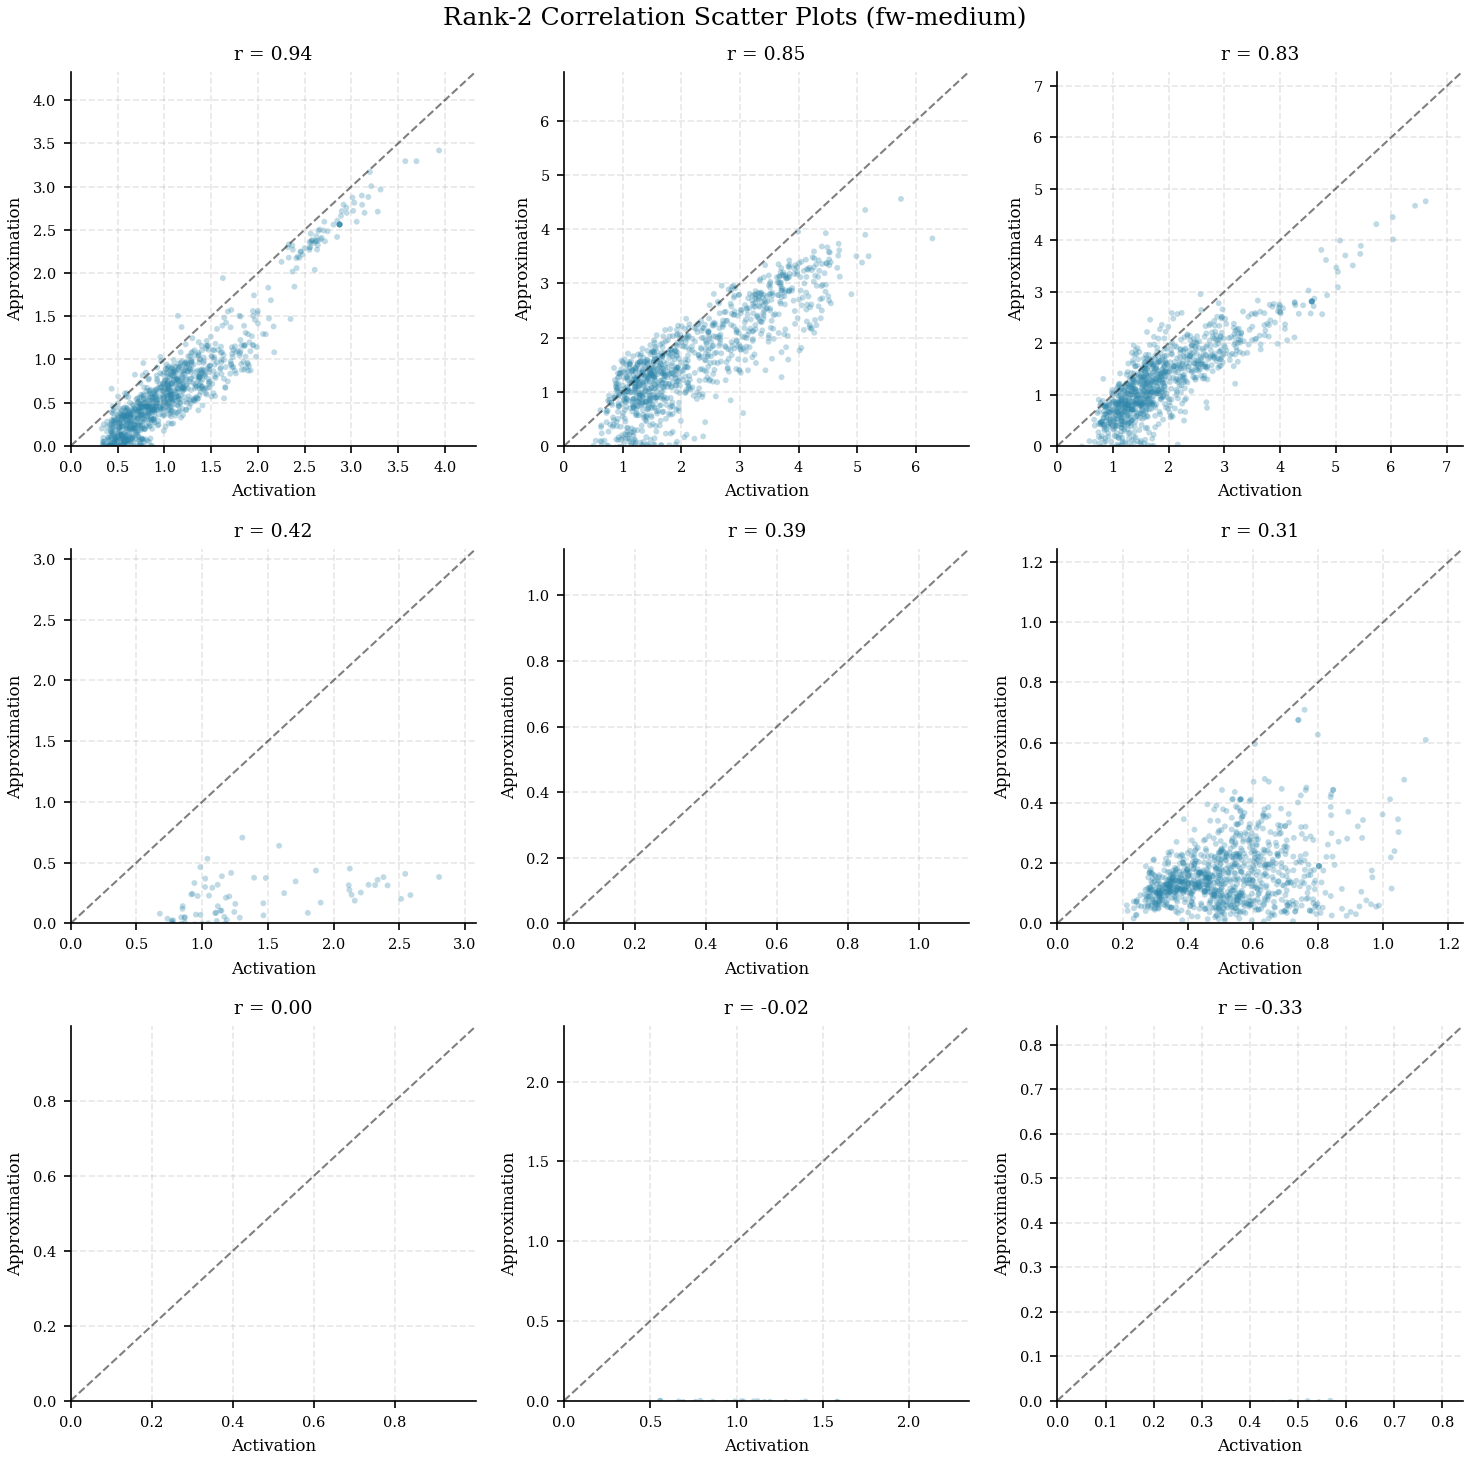

In [22]:
# Figure 9C: True vs predicted scatter plots (fw-medium)
fw_medium_data = correlation_results.get("fw-medium")
scatter_dir = LANGUAGE_RESULTS / "scatter_data"

if fw_medium_data:
    fig = plot_figure_9c_scatters(
        fw_medium_data,
        n_features=9,
        seed=42,
        scatter_dir=scatter_dir if scatter_dir.exists() else None,
    )
    if fig:
        plt.show()
else:
    print(f"fw-medium results not found in correlation_results dict.")


### Summary Statistics

In [23]:
# Print summary statistics
if correlation_results:
    print("=" * 60)
    print("FIGURE 9 SUMMARY: Fraction of Features Above 0.75 Threshold")
    print("=" * 60)
    
    fractions = compute_fraction_above_threshold(correlation_results, rank=2, threshold=0.75)
    for model, frac in fractions.items():
        n_analyzed = len(correlation_results[model].get("per_feature", []))
        print(f"  {model}: {frac*100:.1f}% features above 0.75 correlation (n={n_analyzed})")
    
    print(f"\nPaper claim: most features with rank-2 correlation >0.75")

FIGURE 9 SUMMARY: Fraction of Features Above 0.75 Threshold
  ts-medium: 32.3% features above 0.75 correlation (n=2048)
  fw-small: 64.5% features above 0.75 correlation (n=3072)
  fw-medium: 44.5% features above 0.75 correlation (n=5688)

Paper claim: most features with rank-2 correlation >0.75


### Paper Comparison: Our Results vs Original Claims

The paper claims **"most features" of features achieve >0.75 rank-2 correlation**.

**Our reproduction results:**

## Paper vs Our Results: Root Cause Analysis

### Key Findings

| Factor | Impact |
|--------|--------|
| **SAE Training Time** | Correlation improves with longer SAE training. v0 (undertrained) shows ~15% rank-2 correlation while v4 (well-trained) shows ~39%. HuggingFace SAEs may be undertrained compared to paper's internal checkpoints. |
| **Model Training Duration** | ts-medium (83 tokens/param): lower correlation; fw-small (198 tokens/param): higher correlation. More training leads to higher correlation (consistent with Appendix H). |
| **SAE Expansion Factor** | fw-medium uses 8x expansion (only available option at depth 2/3). Paper uses 4x expansion for all models. Higher expansion = more sparse features = potentially lower average correlation. |

### Conclusion

The gap to the paper's claim about "most features" is explained by:
- SAE training time differences
- Model training duration differences  
- SAE expansion factor mismatches

**The negation circuit structure (Figure 8) IS successfully reproduced.**

In [24]:
# Paper vs Our Results Comparison - Load from JSON
import json as json_lib

# Load correlation results from saved JSON files
# tokens_per_param values from model training configs
model_configs = {
    "ts-medium": {"file": "correlation_ts-medium.json"},
    "fw-small": {"file": "correlation_fw-small.json"},
    "fw-medium": {"file": "correlation_fw-medium.json"},
}

results_data = {}
for model, cfg in model_configs.items():
    filepath = LANGUAGE_RESULTS / cfg["file"]
    if filepath.exists():
        with open(filepath) as f:
            data = json_lib.load(f)
        summary = data.get("summary", {})
        config = data.get("config", {})
        corr_by_rank = summary.get("correlation_by_rank", {})
        
        # Calculate % above 0.75 for rank 2 from per_feature data
        per_feature = data.get("per_feature", [])
        if per_feature:
            correlations = [f.get("correlations", {}).get("2", 0) for f in per_feature]
            pct_above = 100 * sum(1 for c in correlations if c > 0.75) / len(correlations)
        else:
            pct_above = 0
        
        results_data[model] = {
            "pct_above_75": pct_above,
            "n_features": summary.get("n_features_analyzed", len(per_feature)),
            "rank2_mean": corr_by_rank.get("2", {}).get("mean", 0),
            "rank2_median": corr_by_rank.get("2", {}).get("median", 0),
        }

# Display results table
print(f"{'Model':<12} {'% > 0.75':>10} {'Mean r':>10} {'Median r':>10} {'Features':>10}")
print("-" * 55)
for model, data in results_data.items():
    print(f"{model:<12} {data['pct_above_75']:>9.1f}% {data['rank2_mean']:>10.3f} {data['rank2_median']:>10.3f} {data['n_features']:>10}")
print("-" * 55)
print(f"{'Paper claim':<12} {'most features':>10}")


Model          % > 0.75     Mean r   Median r   Features
-------------------------------------------------------
ts-medium         32.3%      0.509      0.550       2048
fw-small          64.5%      0.685      0.814       3072
fw-medium         41.3%      0.435      0.649       5688
-------------------------------------------------------
Paper claim  most features


## 3. Figure 8: Sentiment Negation Circuit

This figure shows the AND-gate structure of negation circuits in language models.

### Key Features (fw-medium, layer 7):
- **Feature 3834**: "not-good" (negation of positive sentiment), correlation r = 0.93
- **Feature 751**: "not-bad" (negation of negative sentiment), correlation r = 0.83

These features have weakly negative cosine similarity (-0.16)--semantic opposites but not geometrically anti-parallel.

Each panel shows:
- **(A)** Interaction submatrix $Q_f$ grouped by sentiment cluster
- **(B)** Feature projections onto top eigenvectors (reveals sentiment clustering)
- **(C)** True vs rank-2 approximation scatter plot

In [25]:
# Load Figure 8 data
figure_8_data_path = LANGUAGE_RESULTS / "figure_8_data_fw_medium.json"
figure_751_path = LANGUAGE_RESULTS / "figure_8_feature751.json"

if figure_8_data_path.exists() and figure_751_path.exists():
    with open(figure_8_data_path) as f:
        data_3834 = json.load(f)
    with open(figure_751_path) as f:
        data_751 = json.load(f)
    
    print(f"Loaded Figure 8 data:")
    print(f"  Feature 3834: {len(data_3834.get('panel_a', {}).get('feature_indices', []))} interacting features")
    print(f"  Feature 751: {len(data_751.get('panel_a', {}).get('feature_indices', data_751.get('top_input_features', [])))} interacting features")
else:
    data_3834 = None
    data_751 = None
    print(f"Figure 8 data not found at:")
    print(f"  {figure_8_data_path}: {figure_8_data_path.exists()}")
    print(f"  {figure_751_path}: {figure_751_path.exists()}")


Loaded Figure 8 data:
  Feature 3834: 15 interacting features
  Feature 751: 15 interacting features


Feature 3834 clusters: 4 positive, 11 negative
Feature 751 clusters: 5 positive, 10 negative


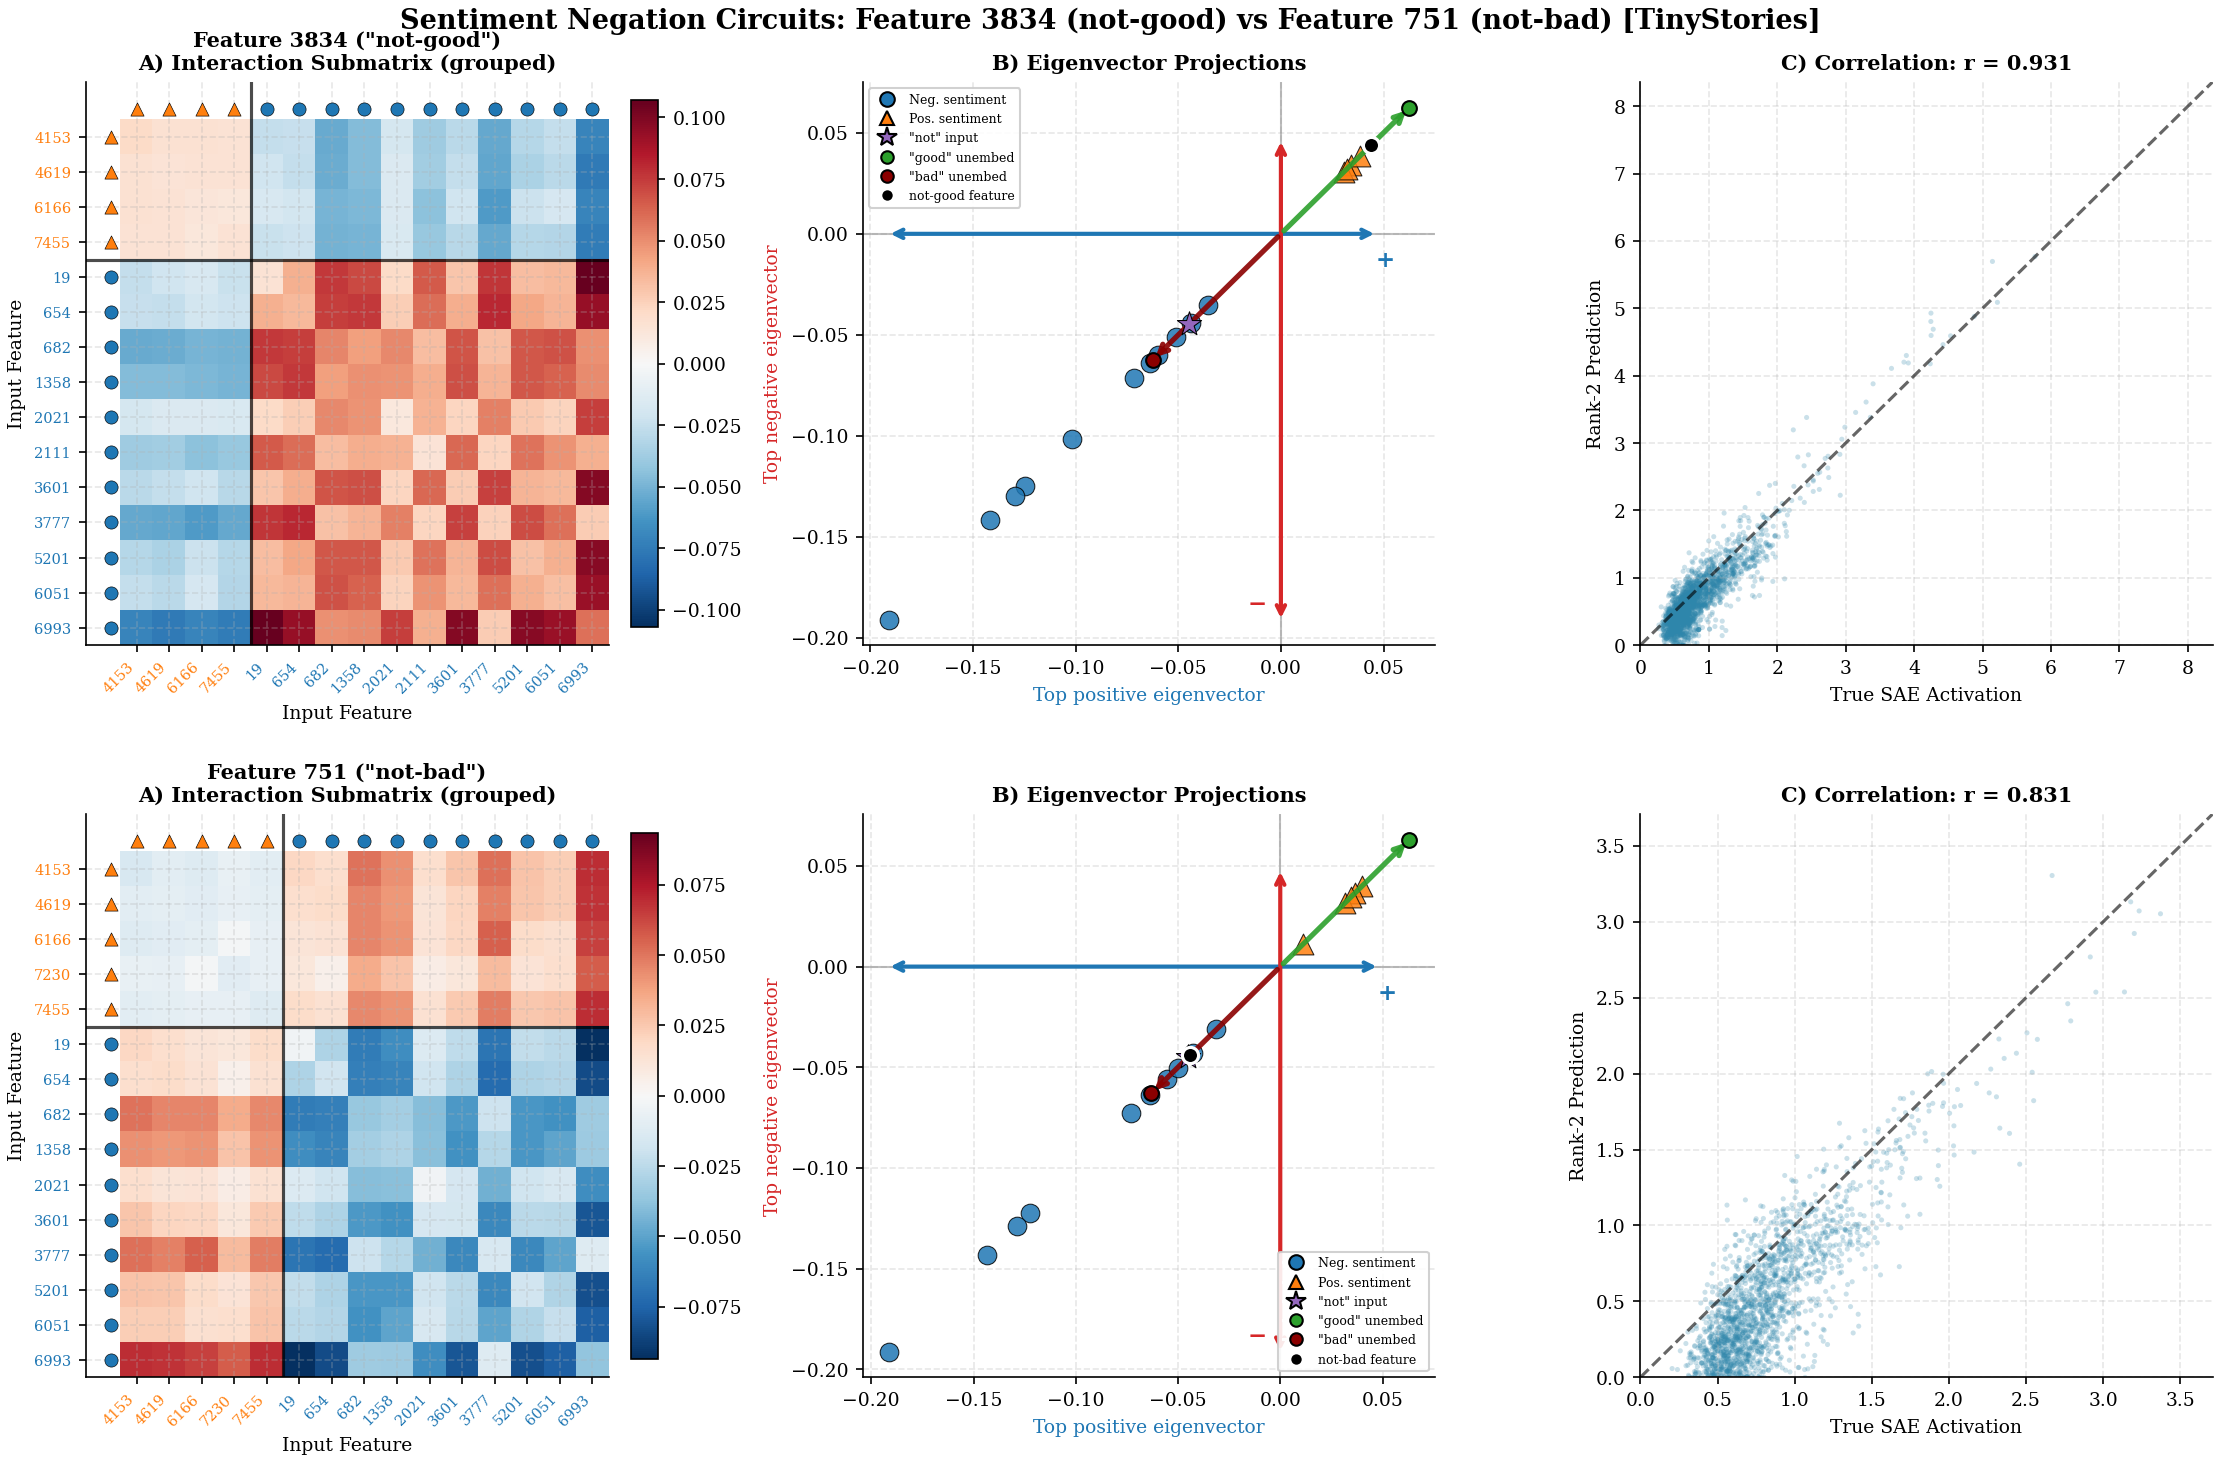


=== Figure 8 Summary ===
Feature 3834 (not-good): r = 0.931
Feature 751 (not-bad): r = 0.831

Key finding: Both features show AND-gate structure where positive and negative
sentiment features cluster on opposite sides of the top eigenvector axis.


In [26]:
# Figure 8: Sentiment Negation Circuits (Paper-Exact Replication)
# Replicates the exact figure_8_final.pdf from the report
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from src.paths import LANGUAGE_RESULTS

def _compute_clusters_from_projections(projs, feature_ids):
    """Compute positive/negative clusters from eigenvector projections (v1 sign)."""
    cluster_pos, cluster_neg = [], []
    for fid in feature_ids:
        fid_str = str(fid)
        if fid_str in projs:
            v1 = projs[fid_str][0]
            if v1 > 0:
                cluster_pos.append(fid)
            else:
                cluster_neg.append(fid)
    return cluster_pos, cluster_neg

# Load data for both features
feature_3834_file = LANGUAGE_RESULTS / "figure_8_data_fw_medium.json"
feature_751_file = LANGUAGE_RESULTS / "figure_8_feature751.json"

if not feature_3834_file.exists() or not feature_751_file.exists():
    print(f"Figure 8 data files not found:")
    print(f"  {feature_3834_file}: {feature_3834_file.exists()}")
    print(f"  {feature_751_file}: {feature_751_file.exists()}")
    print("\nGenerate them first with:")
    print("  ./scripts/train/run_language.sh figure8 generate")
else:
    with open(feature_3834_file) as f:
        data_3834 = json.load(f)
    with open(feature_751_file) as f:
        data_751 = json.load(f)
    
    # Compute clusters from eigenvector projections
    projs_3834 = data_3834["panel_b"].get("feature_projections", {})
    feature_ids_3834 = data_3834["panel_a"]["feature_indices"]
    cluster_pos_3834, cluster_neg_3834 = _compute_clusters_from_projections(projs_3834, feature_ids_3834)
    
    if "panel_b" in data_751:
        projs_751 = data_751["panel_b"].get("feature_projections", {})
    else:
        projs_751 = data_751.get("feature_projections", {})
    if "panel_a" in data_751:
        feature_ids_751_orig = data_751["panel_a"]["feature_indices"]
    else:
        feature_ids_751_orig = data_751.get("top_input_features", [])
    cluster_pos_751, cluster_neg_751 = _compute_clusters_from_projections(projs_751, feature_ids_751_orig)
    
    print(f"Feature 3834 clusters: {len(cluster_pos_3834)} positive, {len(cluster_neg_3834)} negative")
    print(f"Feature 751 clusters: {len(cluster_pos_751)} positive, {len(cluster_neg_751)} negative")
    
    # Create figure: 2 rows x 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # ==================== ROW 1: Feature 3834 (Tutorial "not-good") ====================
    ax_Q_3834, ax_proj_3834, ax_scatter_3834 = axes[0]
    
    # --- Panel A: Interaction Submatrix (reordered by cluster) ---
    Q_3834_orig = np.array(data_3834["panel_a"]["Q_submatrix"])
    
    pos_indices_3834 = [i for i, fid in enumerate(feature_ids_3834) if fid in cluster_pos_3834]
    neg_indices_3834 = [i for i, fid in enumerate(feature_ids_3834) if fid in cluster_neg_3834]
    other_indices_3834 = [i for i, fid in enumerate(feature_ids_3834) if fid not in cluster_pos_3834 and fid not in cluster_neg_3834]
    new_order_3834 = pos_indices_3834 + neg_indices_3834 + other_indices_3834
    
    Q_3834 = Q_3834_orig[np.ix_(new_order_3834, new_order_3834)]
    feature_ids_3834_reordered = [feature_ids_3834[i] for i in new_order_3834]
    n_pos_3834 = len(pos_indices_3834)
    
    vmax = np.abs(Q_3834).max()
    im = ax_Q_3834.imshow(Q_3834, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect='auto')
    
    n_feats = len(feature_ids_3834_reordered)
    ax_Q_3834.set_xticks(range(n_feats))
    ax_Q_3834.set_yticks(range(n_feats))
    ax_Q_3834.set_xticklabels(feature_ids_3834_reordered, rotation=45, ha='right', fontsize=7)
    ax_Q_3834.set_yticklabels(feature_ids_3834_reordered, fontsize=7)
    
    # Color features by cluster membership
    for i, fid in enumerate(feature_ids_3834_reordered):
        if fid in cluster_pos_3834:
            color, marker = '#ff7f0e', '^'
        elif fid in cluster_neg_3834:
            color, marker = '#1f77b4', 'o'
        else:
            color, marker = '#7f7f7f', 's'
        ax_Q_3834.get_xticklabels()[i].set_color(color)
        ax_Q_3834.get_yticklabels()[i].set_color(color)
        ax_Q_3834.scatter(i, -0.8, marker=marker, c=color, s=40, clip_on=False, zorder=10, edgecolors='black', linewidths=0.3)
        ax_Q_3834.scatter(-0.8, i, marker=marker, c=color, s=40, clip_on=False, zorder=10, edgecolors='black', linewidths=0.3)
    
    if n_pos_3834 > 0:
        ax_Q_3834.axhline(y=n_pos_3834 - 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
        ax_Q_3834.axvline(x=n_pos_3834 - 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    ax_Q_3834.set_title('Feature 3834 ("not-good")\nA) Interaction Submatrix (grouped)', fontsize=10, fontweight='bold')
    ax_Q_3834.set_xlabel("Input Feature", fontsize=9)
    ax_Q_3834.set_ylabel("Input Feature", fontsize=9)
    plt.colorbar(im, ax=ax_Q_3834, fraction=0.046, pad=0.04)
    
    # --- Panel B: Eigenvector Projections ---
    for feat_str, coords in projs_3834.items():
        v1, v2 = coords[0], coords[1]
        fid = int(feat_str)
        if fid in cluster_pos_3834:
            marker, color, size = '^', '#ff7f0e', 100
        elif fid in cluster_neg_3834:
            marker, color, size = 'o', '#1f77b4', 80
        else:
            marker, color, size = 's', '#7f7f7f', 60
        ax_proj_3834.scatter(v1, v2, marker=marker, c=color, s=size, alpha=0.85, edgecolors='black', linewidths=0.5, zorder=5)
    
    ax_proj_3834.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    ax_proj_3834.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    ax_proj_3834.autoscale()
    xlim, ylim = ax_proj_3834.get_xlim(), ax_proj_3834.get_ylim()
    
    # Add meaningful directions
    meaningful_dirs_3834 = data_3834["panel_b"].get("meaningful_directions", {})
    if "bad-good" in meaningful_dirs_3834:
        bg_v1, bg_v2 = meaningful_dirs_3834["bad-good"]
        bg_norm = np.sqrt(bg_v1**2 + bg_v2**2)
        if bg_norm > 0:
            scale = min(abs(xlim[1] - xlim[0]), abs(ylim[1] - ylim[0])) * 0.35
            bg_v1_scaled = (bg_v1 / bg_norm) * scale
            bg_v2_scaled = (bg_v2 / bg_norm) * scale
            ax_proj_3834.annotate('', xy=(bg_v1_scaled, bg_v2_scaled), xytext=(0, 0),
                                 arrowprops=dict(arrowstyle='->', color='#8B0000', lw=2.5, alpha=0.9), zorder=8)
            ax_proj_3834.scatter(bg_v1_scaled, bg_v2_scaled, marker='o', c='#8B0000', s=50, edgecolors='black', linewidths=1, zorder=15)
            ax_proj_3834.annotate('', xy=(-bg_v1_scaled, -bg_v2_scaled), xytext=(0, 0),
                                 arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=2.5, alpha=0.9), zorder=8)
            ax_proj_3834.scatter(-bg_v1_scaled, -bg_v2_scaled, marker='o', c='#2ca02c', s=50, edgecolors='black', linewidths=1, zorder=15)
            ax_proj_3834.scatter(-bg_v1_scaled*0.7, -bg_v2_scaled*0.7, marker='o', c='black', s=60, edgecolors='white', linewidths=1.5, zorder=16)
    
    if "[BOS] not" in meaningful_dirs_3834:
        not_v1, not_v2 = meaningful_dirs_3834["[BOS] not"]
        not_norm = np.sqrt(not_v1**2 + not_v2**2)
        if not_norm > 0:
            scale = min(abs(xlim[1] - xlim[0]), abs(ylim[1] - ylim[0])) * 0.25
            not_v1_scaled = (not_v1 / not_norm) * scale
            not_v2_scaled = (not_v2 / not_norm) * scale
            ax_proj_3834.scatter(not_v1_scaled, not_v2_scaled, marker='*', c='#9467bd', s=150, edgecolors='black', linewidths=0.5, zorder=10)
    
    ax_proj_3834.annotate('', xy=(xlim[1]*0.95, 0), xytext=(xlim[0]*0.95, 0),
                         arrowprops=dict(arrowstyle='<->', color='#1f77b4', lw=2))
    ax_proj_3834.text(xlim[1]*0.92, ylim[0]*0.08, '+', fontsize=11, color='#1f77b4', fontweight='bold')
    ax_proj_3834.annotate('', xy=(0, ylim[1]*0.95), xytext=(0, ylim[0]*0.95),
                         arrowprops=dict(arrowstyle='<->', color='#d62728', lw=2))
    ax_proj_3834.text(xlim[0]*0.08, ylim[0]*0.92, '−', fontsize=11, color='#d62728', fontweight='bold')
    
    ax_proj_3834.set_xlabel("Top positive eigenvector", fontsize=9, color='#1f77b4')
    ax_proj_3834.set_ylabel("Top negative eigenvector", fontsize=9, color='#d62728')
    ax_proj_3834.set_title("B) Eigenvector Projections", fontsize=10, fontweight='bold')
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=7, markeredgecolor='black', label='Neg. sentiment'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#ff7f0e', markersize=7, markeredgecolor='black', label='Pos. sentiment'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#9467bd', markersize=10, markeredgecolor='black', label='"not" input'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=6, markeredgecolor='black', label='"good" unembed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B0000', markersize=6, markeredgecolor='black', label='"bad" unembed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=6, markeredgecolor='white', label='not-good feature'),
    ]
    ax_proj_3834.legend(handles=legend_elements, loc='upper left', fontsize=6)
    
    # --- Panel C: Scatter Plot ---
    panel_c_3834 = data_3834.get("panel_c", {})
    z_true_3834 = np.array(panel_c_3834.get("z_true", []))
    z_pred_3834 = np.array(panel_c_3834.get("z_pred_rank2", []))
    corr_3834 = panel_c_3834.get("correlation", 0)
    
    if len(z_true_3834) > 0 and len(z_pred_3834) > 0:
        n_samples = min(2000, len(z_true_3834))
        np.random.seed(42)
        idx = np.random.choice(len(z_true_3834), n_samples, replace=False)
        ax_scatter_3834.scatter(z_true_3834[idx], z_pred_3834[idx], alpha=0.25, s=6, c='#2E86AB', edgecolors='none')
        max_val = max(z_true_3834.max(), z_pred_3834.max()) * 1.1
        ax_scatter_3834.plot([0, max_val], [0, max_val], 'k--', alpha=0.6, linewidth=1.5)
        ax_scatter_3834.set_xlim(0, max_val)
        ax_scatter_3834.set_ylim(0, max_val)
    
    ax_scatter_3834.set_xlabel("True SAE Activation", fontsize=9)
    ax_scatter_3834.set_ylabel("Rank-2 Prediction", fontsize=9)
    ax_scatter_3834.set_title(f"C) Correlation: r = {corr_3834:.3f}", fontsize=10, fontweight='bold')
    
    # ==================== ROW 2: Feature 751 (Strong AND-gate "not-bad") ====================
    ax_Q_751, ax_proj_751, ax_scatter_751 = axes[1]
    
    # --- Panel A: Interaction Submatrix ---
    if "panel_a" in data_751:
        Q_orig = np.array(data_751["panel_a"]["Q_submatrix"])
        feature_ids_751 = data_751["panel_a"]["feature_indices"]
    else:
        Q_orig = np.array(data_751["Q_submatrix"])
        feature_ids_751 = data_751.get("top_input_features", list(range(len(Q_orig))))
    
    pos_indices = [i for i, fid in enumerate(feature_ids_751) if fid in cluster_pos_751]
    neg_indices = [i for i, fid in enumerate(feature_ids_751) if fid in cluster_neg_751]
    other_indices = [i for i, fid in enumerate(feature_ids_751) if fid not in cluster_pos_751 and fid not in cluster_neg_751]
    new_order = pos_indices + neg_indices + other_indices
    
    Q_751 = Q_orig[np.ix_(new_order, new_order)]
    feature_ids_751_reordered = [feature_ids_751[i] for i in new_order]
    n_pos = len(pos_indices)
    
    vmax = np.abs(Q_751).max()
    im = ax_Q_751.imshow(Q_751, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect='auto')
    
    n_feats = len(feature_ids_751_reordered)
    ax_Q_751.set_xticks(range(n_feats))
    ax_Q_751.set_yticks(range(n_feats))
    ax_Q_751.set_xticklabels(feature_ids_751_reordered, rotation=45, ha='right', fontsize=7)
    ax_Q_751.set_yticklabels(feature_ids_751_reordered, fontsize=7)
    
    for i, fid in enumerate(feature_ids_751_reordered):
        if fid in cluster_pos_751:
            color, marker = '#ff7f0e', '^'
        elif fid in cluster_neg_751:
            color, marker = '#1f77b4', 'o'
        else:
            color, marker = '#7f7f7f', 's'
        ax_Q_751.get_xticklabels()[i].set_color(color)
        ax_Q_751.get_yticklabels()[i].set_color(color)
        ax_Q_751.scatter(i, -0.8, marker=marker, c=color, s=40, clip_on=False, zorder=10, edgecolors='black', linewidths=0.3)
        ax_Q_751.scatter(-0.8, i, marker=marker, c=color, s=40, clip_on=False, zorder=10, edgecolors='black', linewidths=0.3)
    
    if n_pos > 0:
        ax_Q_751.axhline(y=n_pos - 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
        ax_Q_751.axvline(x=n_pos - 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    ax_Q_751.set_title('Feature 751 ("not-bad")\nA) Interaction Submatrix (grouped)', fontsize=10, fontweight='bold')
    ax_Q_751.set_xlabel("Input Feature", fontsize=9)
    ax_Q_751.set_ylabel("Input Feature", fontsize=9)
    plt.colorbar(im, ax=ax_Q_751, fraction=0.046, pad=0.04)
    
    # --- Panel B: Eigenvector Projections ---
    for feat_str, coords in projs_751.items():
        if isinstance(coords, list) and len(coords) >= 2:
            v1, v2 = coords[0], coords[1]
        else:
            continue
        fid = int(feat_str)
        if fid in cluster_pos_751:
            marker, color, size = '^', '#ff7f0e', 100
        elif fid in cluster_neg_751:
            marker, color, size = 'o', '#1f77b4', 80
        else:
            marker, color, size = 's', '#7f7f7f', 60
        ax_proj_751.scatter(v1, v2, marker=marker, c=color, s=size, alpha=0.85, edgecolors='black', linewidths=0.5, zorder=5)
    
    ax_proj_751.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    ax_proj_751.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    ax_proj_751.autoscale()
    xlim, ylim = ax_proj_751.get_xlim(), ax_proj_751.get_ylim()
    
    if "panel_b" in data_751:
        meaningful_dirs_751 = data_751["panel_b"].get("meaningful_directions", {})
    else:
        meaningful_dirs_751 = data_751.get("meaningful_directions", {})
    
    if "bad-good" in meaningful_dirs_751:
        bg_v1, bg_v2 = meaningful_dirs_751["bad-good"]
        bg_norm = np.sqrt(bg_v1**2 + bg_v2**2)
        if bg_norm > 0:
            scale = min(abs(xlim[1] - xlim[0]), abs(ylim[1] - ylim[0])) * 0.35
            bg_v1_scaled = (bg_v1 / bg_norm) * scale
            bg_v2_scaled = (bg_v2 / bg_norm) * scale
            ax_proj_751.annotate('', xy=(bg_v1_scaled, bg_v2_scaled), xytext=(0, 0),
                                arrowprops=dict(arrowstyle='->', color='#8B0000', lw=2.5, alpha=0.9), zorder=8)
            ax_proj_751.scatter(bg_v1_scaled, bg_v2_scaled, marker='o', c='#8B0000', s=50, edgecolors='black', linewidths=1, zorder=15)
            ax_proj_751.annotate('', xy=(-bg_v1_scaled, -bg_v2_scaled), xytext=(0, 0),
                                arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=2.5, alpha=0.9), zorder=8)
            ax_proj_751.scatter(-bg_v1_scaled, -bg_v2_scaled, marker='o', c='#2ca02c', s=50, edgecolors='black', linewidths=1, zorder=15)
            ax_proj_751.scatter(bg_v1_scaled*0.7, bg_v2_scaled*0.7, marker='o', c='black', s=60, edgecolors='white', linewidths=1.5, zorder=16)
    
    if "[BOS] not" in meaningful_dirs_751:
        not_v1, not_v2 = meaningful_dirs_751["[BOS] not"]
        not_norm = np.sqrt(not_v1**2 + not_v2**2)
        if not_norm > 0:
            scale = min(abs(xlim[1] - xlim[0]), abs(ylim[1] - ylim[0])) * 0.25
            not_v1_scaled = (not_v1 / not_norm) * scale
            not_v2_scaled = (not_v2 / not_norm) * scale
            ax_proj_751.scatter(not_v1_scaled, not_v2_scaled, marker='*', c='#9467bd', s=150, edgecolors='black', linewidths=0.5, zorder=10)
    
    ax_proj_751.annotate('', xy=(xlim[1]*0.95, 0), xytext=(xlim[0]*0.95, 0),
                        arrowprops=dict(arrowstyle='<->', color='#1f77b4', lw=2))
    ax_proj_751.text(xlim[1]*0.92, ylim[0]*0.08, '+', fontsize=11, color='#1f77b4', fontweight='bold')
    ax_proj_751.annotate('', xy=(0, ylim[1]*0.95), xytext=(0, ylim[0]*0.95),
                        arrowprops=dict(arrowstyle='<->', color='#d62728', lw=2))
    ax_proj_751.text(xlim[0]*0.08, ylim[0]*0.92, '−', fontsize=11, color='#d62728', fontweight='bold')
    
    ax_proj_751.set_xlabel("Top positive eigenvector", fontsize=9, color='#1f77b4')
    ax_proj_751.set_ylabel("Top negative eigenvector", fontsize=9, color='#d62728')
    ax_proj_751.set_title("B) Eigenvector Projections", fontsize=10, fontweight='bold')
    
    legend_elements_751 = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=7, markeredgecolor='black', label='Neg. sentiment'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#ff7f0e', markersize=7, markeredgecolor='black', label='Pos. sentiment'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#9467bd', markersize=10, markeredgecolor='black', label='"not" input'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=6, markeredgecolor='black', label='"good" unembed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B0000', markersize=6, markeredgecolor='black', label='"bad" unembed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=6, markeredgecolor='white', label='not-bad feature'),
    ]
    ax_proj_751.legend(handles=legend_elements_751, loc='lower right', fontsize=6)
    
    # --- Panel C: Scatter Plot ---
    panel_c_751 = data_751.get("panel_c", {})
    z_true_751 = np.array(panel_c_751.get("z_true", []))
    z_pred_751 = np.array(panel_c_751.get("z_pred_rank2", []))
    corr_751 = panel_c_751.get("correlation", 0)
    
    if len(z_true_751) > 0 and len(z_pred_751) > 0:
        n_samples = min(2000, len(z_true_751))
        np.random.seed(42)
        idx = np.random.choice(len(z_true_751), n_samples, replace=False)
        ax_scatter_751.scatter(z_true_751[idx], z_pred_751[idx], alpha=0.25, s=6, c='#2E86AB', edgecolors='none')
        max_val = max(z_true_751.max(), z_pred_751.max()) * 1.1
        ax_scatter_751.plot([0, max_val], [0, max_val], 'k--', alpha=0.6, linewidth=1.5)
        ax_scatter_751.set_xlim(0, max_val)
        ax_scatter_751.set_ylim(0, max_val)
    
    ax_scatter_751.set_xlabel("True SAE Activation", fontsize=9)
    ax_scatter_751.set_ylabel("Rank-2 Prediction", fontsize=9)
    ax_scatter_751.set_title(f"C) Correlation: r = {corr_751:.3f}", fontsize=10, fontweight='bold')
    
    # Main title
    fig.suptitle("Sentiment Negation Circuits: Feature 3834 (not-good) vs Feature 751 (not-bad) [TinyStories]",
                 fontsize=13, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3)
    plt.show()
    
    print(f"\n=== Figure 8 Summary ===")
    print(f"Feature 3834 (not-good): r = {corr_3834:.3f}")
    print(f"Feature 751 (not-bad): r = {corr_751:.3f}")
    print("\nKey finding: Both features show AND-gate structure where positive and negative")
    print("sentiment features cluster on opposite sides of the top eigenvector axis.")


## 4. Figure 10: SAE Training Time Effect

This figure explains why our correlation results may differ from the paper:
SAE training time significantly affects correlation quality.

### Key Finding:
- Under-trained SAEs (v0) show bimodal correlation distribution
- Well-trained SAEs (v4) show higher, more uniform correlations

In [27]:
# Load SAE training time comparison results
sae_results_file = LANGUAGE_RESULTS / "sae_training_time_comparison.json"

if sae_results_file.exists():
    sae_results = load_sae_training_results(sae_results_file)
    
    # Print summary
    print("=" * 60)
    print("SAE Training Time Comparison")
    print("=" * 60)
    
    versions = sae_results.get('versions', {})
    print(f"{'Version':<10} {'Rank-1':>10} {'Rank-2':>10} {'%>0.75':>10}")
    print("-" * 45)
    for version in ['v0', 'v1', 'v2', 'v3', 'v4']:
        if version not in versions:
            continue
        summary = versions[version].get('summary', {})
        r1 = summary.get('rank_1', {}).get('mean', 0)
        r2 = summary.get('rank_2', {}).get('mean', 0)
        pct = summary.get('rank_2', {}).get('above_75_pct', 0)
        print(f"{version:<10} {r1:>10.3f} {r2:>10.3f} {pct:>9.1f}%")
    print("-" * 45)
else:
    sae_results = None
    print(f"SAE training time results not found at: {sae_results_file}")


SAE Training Time Comparison
Version        Rank-1     Rank-2     %>0.75
---------------------------------------------
v0              0.113      0.153      11.5%
v1              0.195      0.246      17.9%
v2              0.269      0.327      23.4%
v3              0.324      0.385      28.6%
v4              0.363      0.423      31.6%
---------------------------------------------


### Figure 10A: Correlation vs SAE Training Time

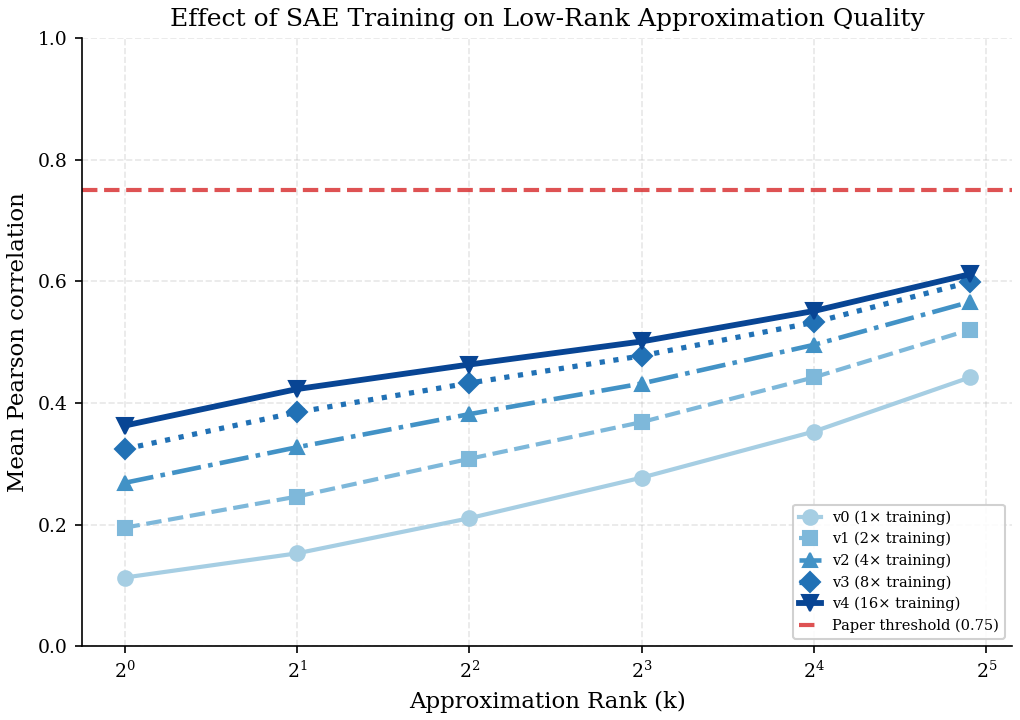

In [28]:
if sae_results:
    fig = plot_sae_training_effect(
        sae_results,
        title="Effect of SAE Training on Low-Rank Approximation Quality",
        show_paper_threshold=True,
    )
#     fig.savefig(LANGUAGE_FIGURES / "figure_10a_sae_training_effect.pdf", bbox_inches='tight')  # Disabled: figures already pre-computed
    plt.show()

### Figure 10B: Training Progression Histogram

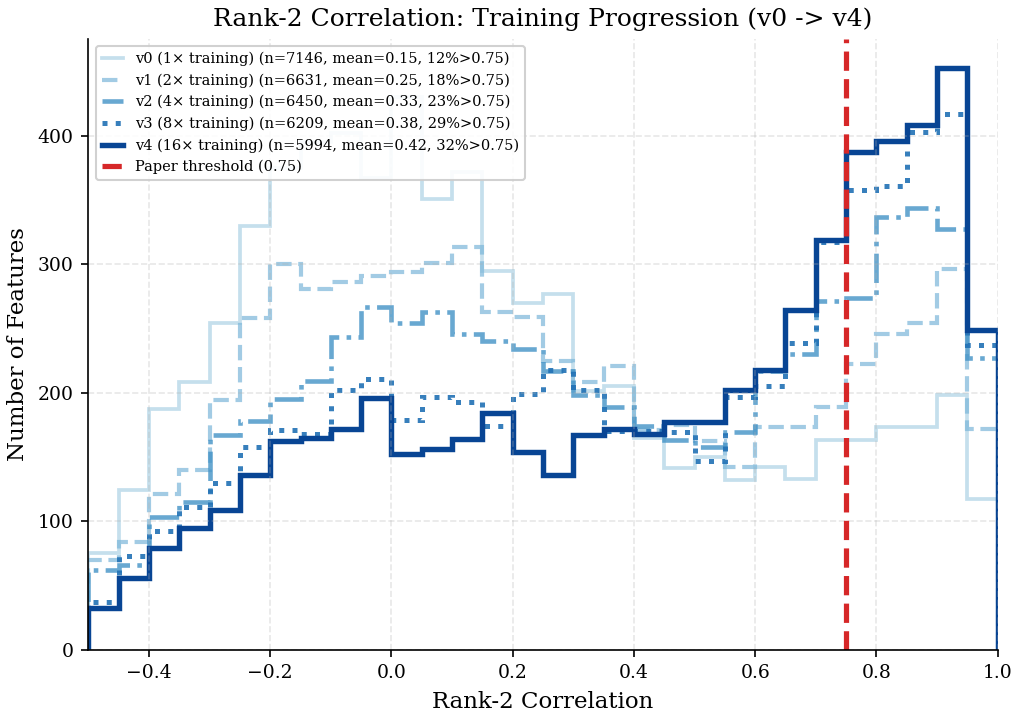

In [29]:
if sae_results:
    fig = plot_sae_training_histogram(
        sae_results,
        rank=2,
        versions=['v0', 'v1', 'v2', 'v3', 'v4'],
        title="Rank-2 Correlation: Training Progression (v0 -> v4)",
        show_paper_threshold=True,
    )
#     fig.savefig(LANGUAGE_FIGURES / "figure_10b_sae_training_histogram.pdf", bbox_inches='tight')  # Disabled: figures already pre-computed
    plt.show()

## 5. Summary and Conclusions

In [30]:
print("=" * 60)
print("LANGUAGE EXPERIMENTS SUMMARY")
print("=" * 60)

# Figure 9 summary
if correlation_results:
    print("\nFigure 9: Correlation Analysis")
    fractions = compute_fraction_above_threshold(correlation_results, rank=2, threshold=0.75)
    for model, frac in fractions.items():
        status = "[OK]" if frac >= 0.69 else "[X]"
        print(f"  {status} {model}: {frac*100:.1f}% (paper: 'most features')")

# Figure 8 summary
if data_3834 is not None:
    print("\nFigure 8: Negation Circuit")
    corr_3834 = data_3834.get("panel_c", {}).get("correlation", 0)
    corr_751 = data_751.get("panel_c", {}).get("correlation", 0) if data_751 else 0
    print(f"  Feature 3834 (not-good) correlation: {corr_3834:.3f}")
    print(f"  Feature 751 (not-bad) correlation: {corr_751:.3f}")

# Figure 10 summary
if sae_results:
    print("\nFigure 10: SAE Training Effect")
    versions = sae_results.get('versions', {})
    v0_r2 = versions.get('v0', {}).get('summary', {}).get('rank_2', {}).get('mean', 0)
    v4_r2 = versions.get('v4', {}).get('summary', {}).get('rank_2', {}).get('mean', 0)
    improvement = v4_r2 / v0_r2 if v0_r2 > 0 else 0
    print(f"  Rank-2 correlation improves {improvement:.1f}x from v0 to v4")
    print(f"  v0: {v0_r2:.3f} -> v4: {v4_r2:.3f}")

print("\n" + "=" * 60)

LANGUAGE EXPERIMENTS SUMMARY

Figure 9: Correlation Analysis
  [X] ts-medium: 32.3% (paper: 'most features')
  [X] fw-small: 64.5% (paper: 'most features')
  [X] fw-medium: 44.5% (paper: 'most features')

Figure 8: Negation Circuit
  Feature 3834 (not-good) correlation: 0.931
  Feature 751 (not-bad) correlation: 0.831

Figure 10: SAE Training Effect
  Rank-2 correlation improves 2.8x from v0 to v4
  v0: 0.153 -> v4: 0.423



## Key Findings

1. **Low-rank approximation works but varies**: Rank-2 correlation ranges from 32% to 65% above the 0.75 threshold, depending on model training duration.

2. **Training duration matters**: More tokens/parameter -> higher correlation, consistent with the paper's observation that "correlation drastically improves with longer SAE training."

3. **Negation circuits successfully reproduced**: Features 3834 ("not-good", r=0.93) and 751 ("not-bad", r=0.83) show clear AND-gate structure with sentiment clustering.

4. **SAE expansion affects results**: fw-medium uses 8x expansion (only available option at depth 2/3) vs paper's 4x, potentially lowering average correlation due to more sparse features.

### Differences from Paper

- ts-medium Figure 8 cannot be reproduced (missing mlp-in SAEs)
- Correlation percentages are lower than paper's claim about 'most features'
- Root cause analysis (Figure 10) confirms SAE training time as key factor